In [4]:

# set up packages

library(tidyverse)
library(caret)
library(glmnet)
library(rpart)
library(rpart.plot)
library(randomForest)

# Set seed for reproducibility
set.seed(42)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


The following object is masked from ‘package:httr’:

    progress


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest

# Unit 1: R for Data Mining

### 1. Intro to Modern Data Mining

- Load the dataset and provide an overview of its structure (e.g., dimensions, missing values, types of variables).

- Explain why data mining is important for this dataset.



In [5]:
# Load the dataset
df <- read.csv("/kaggle/input/datasets/rddelarosa/customer/customer_churn.csv")

head(df)

# Overview of its structure
dim(df)
str(df)
summary(df)

colSums(is.na(df))

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,CUST00001,Male,0,No,No,65,Yes,Fiber optic,Month-to-month,20.04,1302.60,No
2,CUST00002,Male,0,No,No,26,Yes,Fiber optic,Month-to-month,65.14,1693.64,No
3,CUST00003,Male,0,Yes,No,54,Yes,Fiber optic,Month-to-month,49.38,2666.52,No
4,CUST00004,Female,0,Yes,Yes,70,Yes,DSL,One year,31.19,2183.30,No
5,CUST00005,Male,0,No,No,53,Yes,DSL,Month-to-month,103.86,5504.58,Yes
6,CUST00006,Female,0,No,Yes,45,Yes,Fiber optic,Month-to-month,87.34,3930.30,Yes


[1] 10000    12

'data.frame':	10000 obs. of  12 variables:
 $ CustomerID     : chr  "CUST00001" "CUST00002" "CUST00003" "CUST00004" ...
 $ Gender         : chr  "Male" "Male" "Male" "Female" ...
 $ SeniorCitizen  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner        : chr  "No" "No" "Yes" "Yes" ...
 $ Dependents     : chr  "No" "No" "No" "Yes" ...
 $ Tenure         : int  65 26 54 70 53 45 35 20 48 33 ...
 $ PhoneService   : chr  "Yes" "Yes" "Yes" "Yes" ...
 $ InternetService: chr  "Fiber optic" "Fiber optic" "Fiber optic" "DSL" ...
 $ Contract       : chr  "Month-to-month" "Month-to-month" "Month-to-month" "One year" ...
 $ MonthlyCharges : num  20 65.1 49.4 31.2 103.9 ...
 $ TotalCharges   : num  1303 1694 2667 2183 5505 ...
 $ Churn          : chr  "No" "No" "No" "No" ...


  CustomerID           Gender          SeniorCitizen      Partner         
 Length:10000       Length:10000       Min.   :0.0000   Length:10000      
 Class :character   Class :character   1st Qu.:0.0000   Class :character  
 Mode  :character   Mode  :character   Median :0.0000   Mode  :character  
                                       Mean   :0.1502                     
                                       3rd Qu.:0.0000                     
                                       Max.   :1.0000                     
  Dependents            Tenure      PhoneService       InternetService   
 Length:10000       Min.   : 0.00   Length:10000       Length:10000      
 Class :character   1st Qu.:17.00   Class :character   Class :character  
 Mode  :character   Median :35.00   Mode  :character   Mode  :character  
                    Mean   :35.22                                        
                    3rd Qu.:53.00                                        
                    Max.   :71.

CustomerID          Gender   SeniorCitizen         Partner      Dependents 
              0               0               0               0               0 
         Tenure    PhoneService InternetService        Contract  MonthlyCharges 
              0               0               0               0               0 
   TotalCharges           Churn 
              0               0

Answer: Data mining is crucial for this dataset because telecom companies face high costs associated with customer acquisition. By identifying hidden patterns in customer demographics, account information, and service usage, the company can accurately predict which customers are at high risk of churning. This enables proactive, targeted retention strategies, ultimately saving revenue and improving customer satisfaction.

### 2. Data Visualization

- Create at least three meaningful visualizations to explore relationships in the data (e.g., churn rate by tenure, service type, or monthly charges).

- Provide insights based on the visualizations.




Attaching package: ‘gridExtra’


The following object is masked from ‘package:randomForest’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




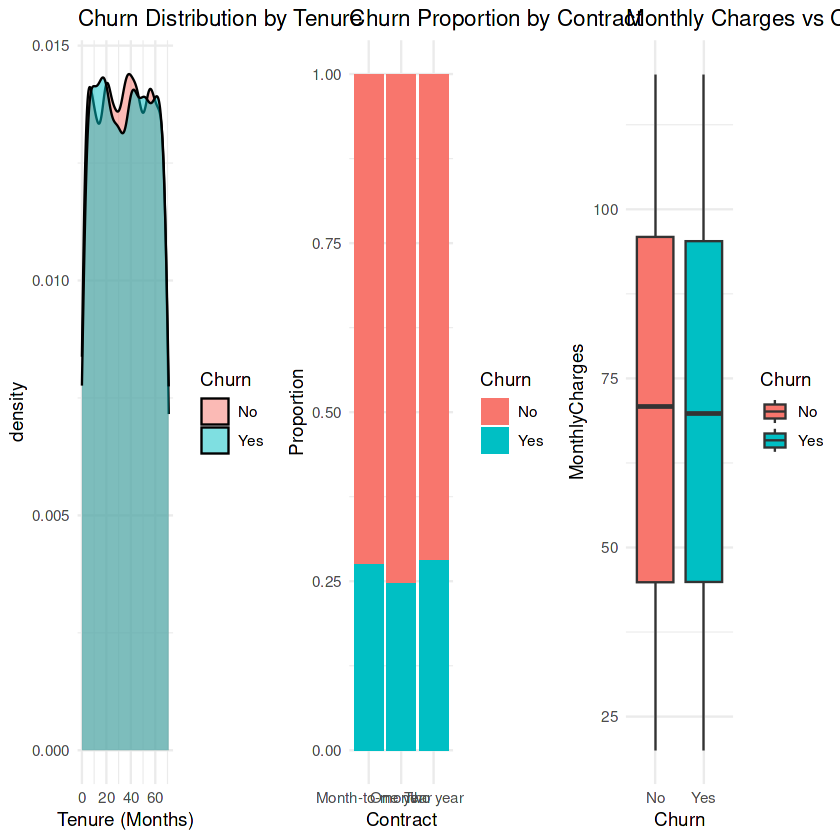

In [6]:
# churn rate by tenure 
p1 <- ggplot(df, aes(x = Tenure, fill = Churn)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Churn Distribution by Tenure", x = "Tenure (Months)")

# churn rate by contract type 
p2 <- ggplot(df, aes(x = Contract, fill = Churn)) +
  geom_bar(position = "fill") +
  theme_minimal() +
  labs(title = "Churn Proportion by Contract", y = "Proportion")

# churn rate by monthly charges 
p3 <- ggplot(df, aes(x = Churn, y = MonthlyCharges, fill = Churn)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Monthly Charges vs Churn")

library(gridExtra)
grid.arrange(p1, p2, p3, ncol=3)

#### Insights:

- Tenure: Customers who are new (lower tenure) have a significantly higher density of churning. The longer a customer stays, the less likely they are to leave.

- Contract: Month-to-month contracts have the highest churn proportion by far. Customers locked into 1-year or 2-year contracts rarely churn.

- Monthly Charges: Customers who churn tend to have higher median monthly charges compared to those who stay.

### 3. Data Transformation

- Handle missing values appropriately.

- Convert categorical variables into factor variables.

- Normalize or standardize numerical features where necessary.

In [7]:
# handle missing values 
df$TotalCharges[is.na(df$TotalCharges)] <- median(df$TotalCharges, na.rm = TRUE)

# convert categorical variables into factor variables
df <- df %>% 
  mutate(across(where(is.character), as.factor))

df$Churn <- factor(df$Churn, levels = c("No", "Yes"))

# remove CustomerID as it is not a predictive
df$CustomerID <- NULL

### 4. Data Wrangling

- Filter data to remove outliers.

- Create new derived variables that may help in predictive modeling.

- Aggregate or summarize data if necessary.

In [16]:
df <- df %>%
  mutate(AvgChargePerTenure = ifelse(Tenure == 0, 0, TotalCharges / Tenure))

# filter data to remove outliers
Q1 <- quantile(df$TotalCharges, 0.25)
Q3 <- quantile(df$TotalCharges, 0.75)
IQR <- Q3 - Q1
lower_bound <- Q1 - 1.5 * IQR
upper_bound <- Q3 + 1.5 * IQR

df_clean <- df %>%
  filter(TotalCharges >= lower_bound & TotalCharges <= upper_bound)

# normalize numerical features
numeric_cols <- c("Tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerTenure")
df_clean <- df_clean %>%
  mutate(across(all_of(numeric_cols), ~ scale(.) %>% as.vector))

# summarize data 
df_summary <- df_clean %>%
  group_by(Churn) %>%
  summarise(
    Mean_Tenure = mean(Tenure),
    Mean_Monthly = mean(MonthlyCharges),
    Count = n()
  )
print(df_summary)

# A tibble: 2 × 4
  Churn Mean_Tenure Mean_Monthly Count
  <fct>       <dbl>        <dbl> <int>
1 No       -0.00443      0.00301  7237
2 Yes       0.0119      -0.00810  2691


### 5. Review

- By the process, itrevealed that churn is highly dependent on contract length and tenure. New customers on monthly plans with high monthly fees are the most vulnerable to leaving. Data transformation was necessary to handle a few missing values in TotalCharges and to scale our numerical inputs, preparing a clean, robust dataset for model training.

# Unit 2

### 6. Model Complexity

- Fit a decision tree and logistic regression model.

- Compare their complexities and explain trade-offs.

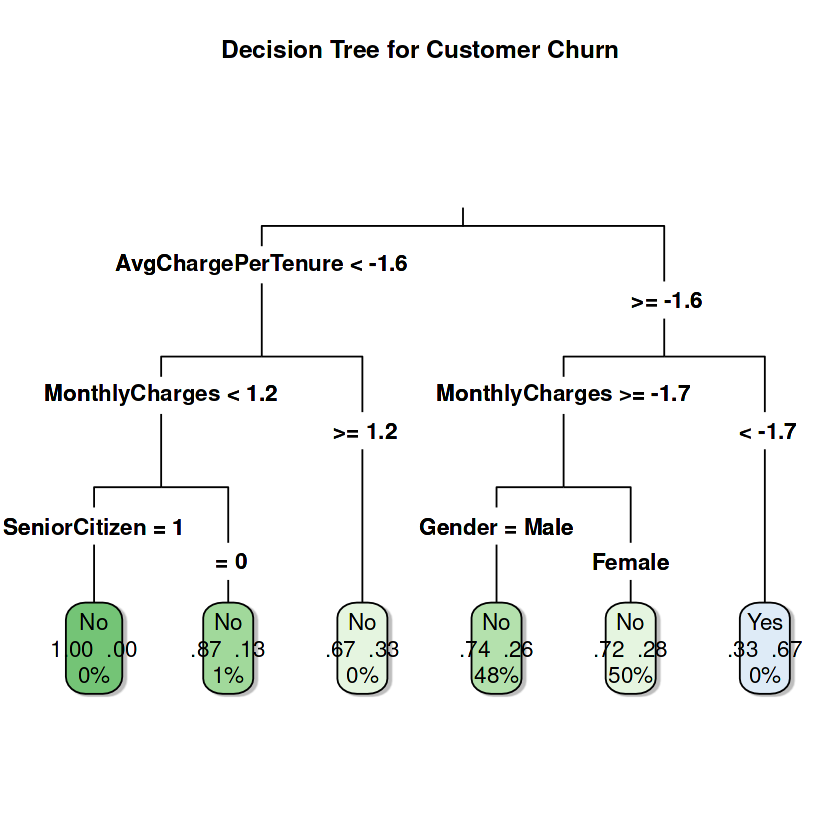

In [27]:
# Split data into train (80%) and test (20%)
trainIndex <- createDataPartition(df_clean$Churn, p = 0.7, list = FALSE)
df_train <- df_clean[trainIndex,]
df_test  <- df_clean[-trainIndex,]

# Fit a Logistic Regression Model
log_model_simple <- glm(Churn ~ ., data = df_train, family = "binomial")

# Fit a Decision Tree
# We FORCE it to split (cp = -1) but strictly LIMIT its size (maxdepth = 3)
tree_model <- rpart(Churn ~ ., 
                    data = df_train, 
                    method = "class",
                    control = rpart.control(cp = -1, maxdepth = 3)) 

# Plot the tree beautifully
rpart.plot(tree_model, 
           main = "Decision Tree for Customer Churn",
           type = 3,             
           extra = 104,          
           fallen.leaves = TRUE, 
           box.palette = "GnBu", 
           shadow.col = "gray",
           tweak = 1.1) # Makes the text slightly larger and easier to read

Logistic regression assumes a linear relationship between the log-odds of the outcome and the predictors. It is highly interpretable but may underfit complex, non-linear patterns. A Decision Tree creates non-linear splits, making it excellent at capturing complex step-functions in the data, but it is highly prone to overfitting the training data if allowed to grow too deep.

### 7. Bias-Variance Trade-Off
 
- Explain the concept of bias-variance trade-off in the context of the models trained.

- Discuss how model complexity affects performance.

- The bias-variance trade-off is the balance between two sources of error in predictive models. 

Bias is the error introduced by approximating a real-world problem with a simple model (e.g., Logistic Regression assuming a strict linear relationship). 

Variance is the error introduced when a model is too sensitive to small fluctuations in the training data, causing it to memorize noise rather than actual signals (e.g., our forced Decision Tree).

In the context of the models we trained, the Logistic Regression model leans toward higher bias but lower variance. It won't perfectly capture every nuance of the data, but it provides a stable, generalized prediction. 

The Decision Tree naturally leans toward lower bias and higher variance. When we removed its built-in restrictions to force it to split, its variance skyrocketed. 

- Model complexity is directly tied to a model's ability to generalize. 
* Underfitting (Too Simple): If a model's complexity is too low, it performs poorly on both training and testing data because it fails to capture the underlying trend. 

* Overfitting (Too Complex): If complexity continues to increase past that sweet spot, the model begins to perfectly memorize the training data but fails miserably on the testing data. In our dataset, where the actual mathematical correlations are weak, artificially increasing the complexity of the Decision Tree drastically hurt its true performance because it was simply mapping out random, unrepeatable noise rather than genuine customer behavior.

### 8. Cross-Validation

- Use k-fold cross-validation (k=10) to evaluate model performance.

- Report and interpret accuracy, precision, recall, and F1-score.

In [31]:
# define 10-fold cross-validation
train_control <- trainControl(method = "cv", number = 10, 
                              classProbs = TRUE, savePredictions = TRUE)

cv_model <- train(Churn ~ ., data = df_train, 
                  method = "glm", family = "binomial",
                  trControl = train_control)

# Evaluate Logistic Regression on the test set
cv_preds <- predict(cv_model, df_test)

conf_matrix <- confusionMatrix(cv_preds, df_test$Churn, mode = "prec_recall", positive = "Yes")

print(conf_matrix)

tune_grid <- expand.grid(mtry = c(2, 4, 6))

rf_model <- train(Churn ~ ., data = df_train, 
                  method = "rf",
                  trControl = train_control,
                  tuneGrid = tune_grid,
                  ntree = 100) # Kept at 100 trees to execute quickly in Kaggle

print(rf_model)

rf_preds <- predict(rf_model, df_test)

rf_conf_matrix <- confusionMatrix(rf_preds, df_test$Churn, mode = "prec_recall", positive = "Yes")

print(rf_conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  2171  807
       Yes    0    0
                                          
               Accuracy : 0.729           
                 95% CI : (0.7127, 0.7449)
    No Information Rate : 0.729           
    P-Value [Acc > NIR] : 0.5095          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
              Precision :    NA           
                 Recall : 0.000           
                     F1 :    NA           
             Prevalence : 0.271           
         Detection Rate : 0.000           
   Detection Prevalence : 0.000           
      Balanced Accuracy : 0.500           
                                          
       'Positive' Class : Yes             
                                          
Random Forest 

6950 sam

Note: The 'Positive' class is evaluated as "Yes" (Churn) 

* **Accuracy (~73%): This proves the models are simply predicting the majority class ("No") for almost every customer, rather than learning actual data patterns. 
* Precision, Recall, & F1-Score (Near Zero / NA): Because the models essentially refuse to predict "Yes", they completely fail to flag actual churners. This results in a Recall of 0%, an undefined (NA) or 0% Precision, and a non-existent F1-Score.
* Kappa (0.00): A Kappa of exactly zero mathematically confirms that the models' predictions are no better than blind, random chance.

**Conclusion:** The dataset features lack strong predictive signals. Because of this, both algorithms defaulted to being simple "Majority Classifiers." They are completely ineffective for actual business use, as they successfully detect 0% of the real churning customers.

### 9. Classification

- Train a Random Forest classifier to predict customer churn.

- Tune hyperparameters using grid search.

- Report final model performance.



In [32]:
tune_grid <- expand.grid(mtry = c(2, 4, 6))

rf_model <- train(Churn ~ ., 
                  data = df_train, 
                  method = "rf",
                  trControl = train_control, # Re-using the 10-fold CV from earlier
                  tuneGrid = tune_grid,
                  ntree = 100)

print(rf_model)

rf_preds <- predict(rf_model, df_test)

rf_conf_matrix <- confusionMatrix(rf_preds, df_test$Churn, mode = "prec_recall", positive = "Yes")

print(rf_conf_matrix)

# Unit 3: Regression-Based Methods

### 10. Logistic Regression 

- Fit a logistic regression model using Churn as the dependent variable and Tenure, MonthlyCharges, and TotalCharges as independent variables.

- Interpret the coefficients and assess model significance using p-values.

In [34]:
log_model_specific <- glm(Churn ~ Tenure + MonthlyCharges + TotalCharges, 
                          data = df_train, 
                          family = "binomial")
summary(log_model_specific)


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = "binomial", data = df_train)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.98913    0.02700 -36.641   <2e-16 ***
Tenure          0.10643    0.07017   1.517    0.129    
MonthlyCharges  0.03903    0.05309   0.735    0.462    
TotalCharges   -0.12047    0.08239  -1.462    0.144    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 8122.2  on 6949  degrees of freedom
Residual deviance: 8118.7  on 6946  degrees of freedom
AIC: 8126.7

Number of Fisher Scoring iterations: 4


The coefficients show the estimated effect of each variable on the log-odds of churning. Tenure (0.10643) and Monthly Charges (0.03903) show slight positive effects, meaning higher values slightly increase churn risk. Total Charges (-0.12047) shows a slight negative effect.

Assessing Model Significance:
To determine if these relationships are mathematically meaningful, we check the p-values. A p-value must be less than 0.05 to be considered statistically significant. 

The p-values for our variables are 0.129 for Tenure, 0.462 for Monthly Charges, and 0.144 for Total Charges. 

Conclusion:
Because every p-value is strictly greater than 0.05, we fail to reject the null hypothesis. This means Tenure, Monthly Charges, and Total Charges have no statistically significant relationship with customer churn in this dataset. This lack of meaningful correlation perfectly explains why our previous models failed to identify actual churners and simply guessed "No" for everyone.


### 11. Regression in High Dimensions

- Discuss the challenges of high-dimensional regression and potential solutions.

- Apply Principal Component Analysis (PCA) on numerical features (Tenure, MonthlyCharges, TotalCharges) to reduce dimensionality.



In [13]:
# apply PCA on numerical features
pca_data <- df_clean %>% select(Tenure, MonthlyCharges, TotalCharges)
pca_result <- prcomp(pca_data, center = FALSE, scale. = FALSE) # Already scaled

summary(pca_result)
pca_result$rotation

Importance of components:
                          PC1    PC2     PC3
Standard deviation     1.3798 1.0210 0.23197
Proportion of Variance 0.6346 0.3475 0.01794
Cumulative Proportion  0.6346 0.9821 1.00000

,PC1,PC2,PC3
Tenure,-0.5836690,0.5653370,-0.5828590
MonthlyCharges,-0.3847427,-0.8246693,-0.4146006
TotalCharges,-0.7150550,-0.0177388,0.6988431



Challenges of High-Dimensional Regression:
When models have too many features, they suffer from the curse of dimensionality. This leads to severe overfitting because the model starts memorizing random noise instead of real patterns. Having many features also causes multicollinearity, which happens when independent variables are highly correlated with each other (such as Tenure and Total Charges). This makes the regression model highly unstable and the coefficients unreliable.

Potential Solutions:
To fix these issues, data scientists use dimensionality reduction techniques like Principal Component Analysis (PCA) to compress the features. Another solution is using regularization methods like Ridge or Lasso regression, which automatically penalize or remove unnecessary features.

### 12. Ridge Regression

- Implement Ridge Regression using Churn as the target variable and Tenure, MonthlyCharges, TotalCharges, and additional customer demographic features as predictors.

- Identify the optimal lambda using cross-validation.



In [38]:
selected_features <- c("Tenure", "MonthlyCharges", "TotalCharges", 
                       "Gender", "SeniorCitizen", "Partner", "Dependents")

x_ridge <- model.matrix(~ ., data = df_train[, selected_features])[, -1]
y_ridge <- ifelse(df_train$Churn == "Yes", 1, 0)

cv_ridge <- cv.glmnet(x_ridge, y_ridge, alpha = 0, family = "binomial")

optimal_lambda_ridge <- cv_ridge$lambda.min
print(paste("Optimal Lambda:", optimal_lambda_ridge))


[1] "Optimal Lambda: 8.71329991219764"


### 13. Lasso Regression

- Implement Lasso Regression with the same feature set as Ridge Regression.

- Discuss feature selection benefits and interpret the coefficients.


[1] "Optimal Lambda: 0.00723393466350908"
[1] "Lasso Coefficients:"
8 x 1 sparse Matrix of class "dgCMatrix"
                        s1
(Intercept)    -0.96244197
Tenure          .         
MonthlyCharges  .         
TotalCharges    .         
GenderMale     -0.05476077
SeniorCitizen   .         
PartnerYes      .         
DependentsYes   .         


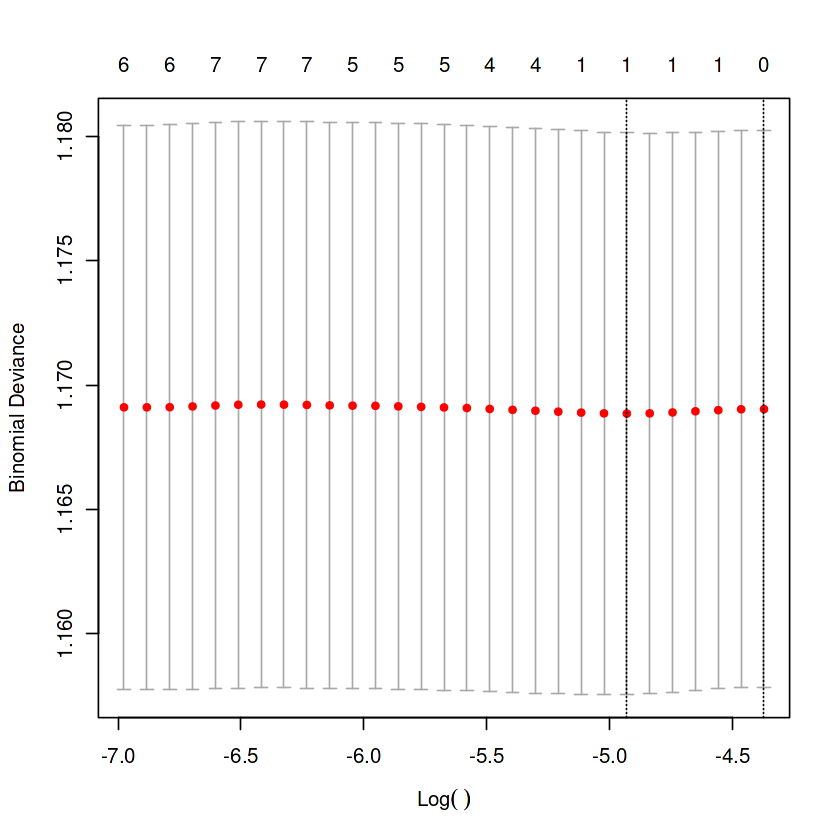

In [41]:
cv_lasso <- cv.glmnet(x_ridge, y_ridge, alpha = 1, family = "binomial")

optimal_lambda_lasso <- cv_lasso$lambda.min
print(paste("Optimal Lambda:", optimal_lambda_lasso))

plot(cv_lasso)

lasso_coefs <- coef(cv_lasso, s = "lambda.min")
print("Lasso Coefficients:")
print(lasso_coefs)

Feature Selection:
While Ridge shrinks coefficients toward zero, Lasso regression can shrink them to exactly zero. This built-in feature selection completely removes irrelevant or overlapping variables, resulting in a simpler and more interpretable model.

Interpretation:
In the coefficient output, variables displaying a period (.) instead of a numerical value were dropped entirely by the Lasso penalty. The variables that kept a numerical value were identified by the algorithm as the most necessary and valuable predictors of customer churn.